In [2]:
import pandas as pd
import numpy as np
import glob
import os

def load_all_logs(log_root):
    all_files = glob.glob(os.path.join(log_root, "**", "*.csv"), recursive=True)
    dfs = []
    for f in all_files:
        if "original" in os.path.basename(f).lower():  # skip corrupted file
            print(f"Skipping: {f}")
            continue
        dfs.append(pd.read_csv(f))
    return pd.concat(dfs, ignore_index=True)

In [ ]:
DATA_DIR = "../data/"
TRAIN_DIR = "../train/"
LOG_ROOT = DATA_DIR + "attack/compromised-scada/attack logs/"
ATTACKER_IP = "185.175.0.7"

FILES = {
    "1s": {
        "benign"   : TRAIN_DIR + "1s_benign_flows.csv",
        "cscada"   : TRAIN_DIR + "1s_cscada_flows.csv",
        "external" : TRAIN_DIR + "1s_external_flows.csv",
    },
    "100ms": {
        "benign"   : TRAIN_DIR + "100ms_benign_flows.csv",
        "cscada"   : TRAIN_DIR + "100ms_cscada_flows.csv",
        "external" : TRAIN_DIR + "100ms_external_flows.csv",
    }
}

TOLERANCE = {"1s": 10, "100ms": 5} #both in seconds we label the windows in this range as attack

In [26]:
# all_files = glob.glob(os.path.join(LOG_ROOT, "**", "*.csv"), recursive=True)

# for f in all_files:
#     df = pd.read_csv(f)
#     print(f"{os.path.basename(os.path.dirname(f))}/{os.path.basename(f)}: {df['Timestamp'].iloc[0]}")

In [8]:
logs = load_all_logs(LOG_ROOT)
logs["timestamp"] = pd.to_datetime(logs["Timestamp"], utc=True, errors="coerce")
logs["unix_ts"] = logs["timestamp"].astype(np.int64) // 10**6
attack_times = logs["unix_ts"].values
print(f"Loaded {len(logs)} attack log entries")
print(f"Time range: {logs['Timestamp'].min()} → {logs['Timestamp'].max()}")

Skipping: ../data/attack/compromised-scada/attack logs/03-21-2023/03-21-2023-1-original.csv
Loaded 1279853 attack log entries
Time range: 2023-03-12 16:12:27.761 → 2023-03-22 03:41:25.376


In [28]:
# df = pd.read_csv(TRAIN_DIR + "1s_cscada_flows.csv")
# print("Flow time range:")
# print(pd.to_datetime(df["time_window"], unit='s').min())
# print(pd.to_datetime(df["time_window"], unit='s').max())

# print("\nAttack log time range:")
# print(logs["Timestamp"].min())
# print(logs["Timestamp"].max())
print(attack_times[:5])
print(pd.to_datetime(attack_times[:5], unit='s'))

[1678637547 1678637547 1678637547 1678637547 1678637547]
DatetimeIndex(['2023-03-12 16:12:27', '2023-03-12 16:12:27',
               '2023-03-12 16:12:27', '2023-03-12 16:12:27',
               '2023-03-12 16:12:27'],
              dtype='datetime64[s]', freq=None)


In [29]:
def label_cscada(df, granularity):
    tol = TOLERANCE[granularity]
    ts = df["time_window"].values.astype(np.float64)
    if granularity == "100ms":
        ts = ts / 10
    
    sorted_atk = np.sort(attack_times)
    
    # For each ts, find closest attack time using binary search
    idx = np.searchsorted(sorted_atk, ts)
    
    # Check neighbor to the left and right
    left  = np.where(idx > 0, sorted_atk[np.clip(idx-1, 0, len(sorted_atk)-1)], np.inf)
    right = np.where(idx < len(sorted_atk), sorted_atk[np.clip(idx, 0, len(sorted_atk)-1)], np.inf)
    
    min_dist = np.minimum(np.abs(ts - left), np.abs(ts - right))
    return (min_dist <= tol).astype(int)

In [30]:
def label_external(df):
    return ((df["ip.src"] == ATTACKER_IP) | (df["ip.dst"] == ATTACKER_IP)).astype(int).values
def label_benign(df):
    return np.zeros(len(df), dtype=int)

In [31]:
# # Check a sample of flow timestamps vs nearest attack times
# df = pd.read_csv(TRAIN_DIR + "1s_cscada_flows.csv")
# ts_sample = df["time_window"].values[:10].astype(np.float64)

# sorted_atk = np.sort(attack_times)

# for t in ts_sample:
#     idx = np.searchsorted(sorted_atk, t)
#     left  = sorted_atk[idx-1] if idx > 0 else None
#     right = sorted_atk[idx]   if idx < len(sorted_atk) else None
#     diff_left  = t - left  if left  is not None else "N/A"
#     diff_right = right - t if right is not None else "N/A"
#     print(f"flow_ts: {t} | left: {left} | right: {right} | diff_left: {diff_left} | diff_right: {diff_right}")

In [32]:
labelers = {
    "benign"   : label_benign,
    "cscada"   : label_cscada,
    "external" : label_external,
}


for gran in ["1s", "100ms"]:
    print(f"\n{'='*40}")
    print(f"Granularity: {gran}")
    for scenario, filepath in FILES[gran].items():
        df = pd.read_csv(filepath)
        
        if scenario == "cscada":
            df["label"] = label_cscada(df, gran)
        elif scenario == "external":
            df["label"] = label_external(df)
        else:
            df["label"] = label_benign(df)

        total    = len(df)
        n_attack = df["label"].sum()
        print(f"\n  [{scenario}]")
        print(f"  Total  : {total}")
        print(f"  Attack : {n_attack} ({100*n_attack/total:.1f}%)")
        print(f"  Benign : {total-n_attack} ({100*(total-n_attack)/total:.1f}%)")

        out_path = TRAIN_DIR + f"labeled_{gran}_{scenario}.csv"
        df.to_csv(out_path, index=False)
        print(f"  Saved  → {out_path}")


Granularity: 1s

  [benign]
  Total  : 854958
  Attack : 0 (0.0%)
  Benign : 854958 (100.0%)
  Saved  → ../train/labeled_1s_benign.csv

  [cscada]
  Total  : 665600
  Attack : 19470 (2.9%)
  Benign : 646130 (97.1%)
  Saved  → ../train/labeled_1s_cscada.csv

  [external]
  Total  : 47184
  Attack : 132 (0.3%)
  Benign : 47052 (99.7%)
  Saved  → ../train/labeled_1s_external.csv

Granularity: 100ms

  [benign]
  Total  : 1478447
  Attack : 0 (0.0%)
  Benign : 1478447 (100.0%)
  Saved  → ../train/labeled_100ms_benign.csv

  [cscada]
  Total  : 1237436
  Attack : 21438 (1.7%)
  Benign : 1215998 (98.3%)
  Saved  → ../train/labeled_100ms_cscada.csv

  [external]
  Total  : 47184
  Attack : 132 (0.3%)
  Benign : 47052 (99.7%)
  Saved  → ../train/labeled_100ms_external.csv


In [3]:
for gran in ["1s", "100ms"]:
    df = pd.read_csv(TRAIN_DIR + f"labeled_{gran}_cscada.csv")
    print(f"\n{gran} cscada:")
    print(f"  Total : {len(df)}")
    print(f"  Attack: {df['label'].sum()} ({100*df['label'].sum()/len(df):.1f}%)")


1s cscada:
  Total : 665600
  Attack: 19470 (2.9%)

100ms cscada:
  Total : 1237436
  Attack: 21438 (1.7%)


In [ ]:
#merging and normalization (skipping this thing because it does not really make sense)
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = [
    "packet_count", "total_bytes", "mean_packet_size", "std_packet_size",
    "iat_mean", "iat_std", "unique_func_codes", "exception_count"
]


for gran in ["1s", "100ms"]:
    for scenario_pair in [("benign", "cscada"), ("benign", "external")]:
        s1, s2 = scenario_pair
        df1 = pd.read_csv(TRAIN_DIR + f"labeled_{gran}_{s1}.csv")
        df2 = pd.read_csv(TRAIN_DIR + f"labeled_{gran}_{s2}.csv")
        
        combined = pd.concat([df1, df2], ignore_index=True)
        combined = combined.sort_values("time_window").reset_index(drop=True)
        
        # Normalize features
        scaler = MinMaxScaler()
        combined[FEATURE_COLS] = scaler.fit_transform(combined[FEATURE_COLS])
        
        # Save scaler for later inference
        import joblib
        joblib.dump(scaler, TRAIN_DIR + f"scaler_{gran}_{s2}.pkl")
        
        print(f"\n{gran} benign+{s2}:")
        print(f"  Total : {len(combined)}")
        print(f"  Attack: {combined['label'].sum()} ({100*combined['label'].sum()/len(combined):.1f}%)")
        
        combined.to_csv(TRAIN_DIR + f"combined_{gran}_{s2}.csv", index=False)
        print(f"  Saved → combined_{gran}_{s2}.csv")



1s benign+cscada:
  Total : 1520558
  Attack: 19470 (1.3%)
  Saved → combined_1s_cscada.csv

1s benign+external:
  Total : 902142
  Attack: 132 (0.0%)
  Saved → combined_1s_external.csv

100ms benign+cscada:
  Total : 2715883
  Attack: 21438 (0.8%)
  Saved → combined_100ms_cscada.csv

100ms benign+external:
  Total : 1525631
  Attack: 132 (0.0%)
  Saved → combined_100ms_external.csv


In [ ]:
# df = pd.read_csv(TRAIN_DIR + "labeled_1s_external.csv")
# print(df[df["label"]==1][["ip.src", "ip.dst", "packet_count"]].head(20))
# very little number of packets to train the thing


In [5]:

SEQ_LEN = 20

FEATURE_COLS = [
    "packet_count", "total_bytes", "mean_packet_size", "std_packet_size",
    "iat_mean", "iat_std", "unique_func_codes", "exception_count"
]

First attack at: 2023-03-12 16:12:27


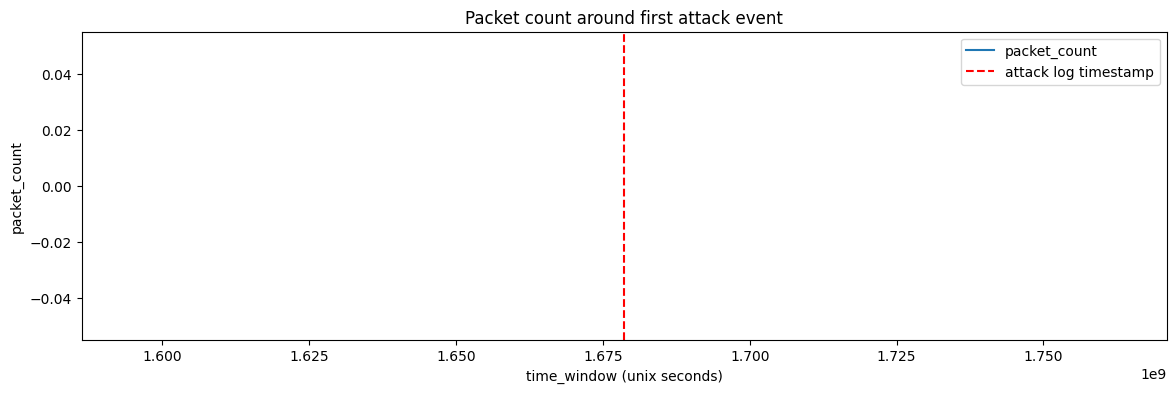

In [9]:
import matplotlib.pyplot as plt

# Pick first attack log timestamp
first_attack_unix = attack_times[0]
print(f"First attack at: {pd.to_datetime(first_attack_unix, unit='s')}")

pair = df[(df["ip.src"]=="185.175.0.3") & (df["ip.dst"]=="185.175.0.8")].sort_values("time_window")

# Plot ±5 minutes around first attack
window_start = first_attack_unix - 300
window_end   = first_attack_unix + 300

zoomed = pair[(pair["time_window"] >= window_start) & (pair["time_window"] <= window_end)]

plt.figure(figsize=(14, 4))
plt.plot(zoomed["time_window"], zoomed["packet_count"], label="packet_count")
plt.axvline(x=first_attack_unix, color='red', linestyle='--', label="attack log timestamp")
plt.legend()
plt.title("Packet count around first attack event")
plt.xlabel("time_window (unix seconds)")
plt.ylabel("packet_count")
plt.show()

In [9]:
def build_sequences(df, seq_len=SEQ_LEN):
    X, y = [], []
    
    for (src, dst), group in df.groupby(["ip.src", "ip.dst"]):
        group = group.sort_values("time_window").reset_index(drop=True)
        features = group[FEATURE_COLS].values
        labels   = group["label"].values
        
        if len(group) < seq_len:
            continue
            
        for i in range(len(group) - seq_len):
            X.append(features[i:i+seq_len])
            y.append(labels[i+seq_len])
    
    return np.array(X), np.array(y)

for gran in ["1s", "100ms"]:
    print(f"\nBuilding sequences for {gran}...")
    df = pd.read_csv(TRAIN_DIR + f"labeled_{gran}_cscada.csv")
    
    X, y = build_sequences(df)
    
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    print(f"  Attack sequences: {y.sum()} ({100*y.sum()/len(y):.1f}%)")
    
    np.save(TRAIN_DIR + f"X_{gran}.npy", X)
    np.save(TRAIN_DIR + f"y_{gran}.npy", y)
    print(f"  Saved → X_{gran}.npy, y_{gran}.npy")


Building sequences for 1s...
  X shape: (665480, 20, 8)
  y shape: (665480,)
  Attack sequences: 19470 (2.9%)
  Saved → X_1s.npy, y_1s.npy

Building sequences for 100ms...
  X shape: (1237316, 20, 8)
  y shape: (1237316,)
  Attack sequences: 21438 (1.7%)
  Saved → X_100ms.npy, y_100ms.npy


In [10]:
from sklearn.preprocessing import MinMaxScaler
import joblib

for gran in ["1s", "100ms"]:
    df = pd.read_csv(TRAIN_DIR + f"labeled_{gran}_cscada.csv")
    
    scaler = MinMaxScaler()
    df[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])
    joblib.dump(scaler, DATA_DIR + f"scaler_{gran}.pkl")
    
    # Rebuild sequences
    X, y = build_sequences(df)
    
    # Split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    np.save(TRAIN_DIR + f"X_train_{gran}.npy", X_train)
    np.save(TRAIN_DIR + f"X_test_{gran}.npy",  X_test)
    np.save(TRAIN_DIR + f"y_train_{gran}.npy", y_train)
    np.save(TRAIN_DIR + f"y_test_{gran}.npy",  y_test)
    
    print(f"{gran}: X_train {X_train.shape} | attacks in train: {y_train.sum()} | attacks in test: {y_test.sum()}")

1s: X_train (532384, 20, 8) | attacks in train: 16538 | attacks in test: 2932
100ms: X_train (989852, 20, 8) | attacks in train: 18026 | attacks in test: 3412


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

gran = "1s"

X_train = np.load(TRAIN_DIR + f"X_train_{gran}.npy")
X_test  = np.load(TRAIN_DIR + f"X_test_{gran}.npy")
y_train = np.load(TRAIN_DIR + f"y_train_{gran}.npy")
y_test  = np.load(TRAIN_DIR + f"y_test_{gran}.npy")

# Handle class imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print(f"Class weights: {class_weight}")

# Model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

# Train
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

model.save(TRAIN_DIR + f"lstm_{gran}.keras")
print("Model saved.")

Class weights: {np.int64(0): np.float64(0.5160299779391524), np.int64(1): np.float64(16.09577941710001)}


/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 70s 73ms/step - accuracy: 0.6222 - auc: 0.5209 - loss: 0.6873 - val_accuracy: 0.9427 - val_auc: 0.5263 - val_loss: 0.6796
Epoch 2/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.7087 - auc: 0.5273 - loss: 0.6867 - val_accuracy: 0.9456 - val_auc: 0.5313 - val_loss: 0.6493
Epoch 3/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.7161 - auc: 0.5314 - loss: 0.6864 - val_accuracy: 0.9452 - val_auc: 0.5329 - val_loss: 0.5992
Epoch 4/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.6660 - auc: 0.5331 - loss: 0.6862 - val_accuracy: 0.5370 - val_auc: 0.5342 - val_loss: 0.6921
Epoch 5/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.6963 - auc: 0.5361 - loss: 0.6860 - val_accuracy: 0.9432 - val_auc: 0.5316 - val_loss: 0.6509
Epoch 6/20
936/936 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.6739 - auc: 0.5405 - loss: 0.6855 - val_accuracy: 0.9429 - val_auc: 0.5356 - val_loss: 0.6379
Model saved.
